# **DANA 4800 Project 2 – Summer Semester 2025**

**Objective:** Outline the purpose and the source of the data

The purpose of this analysis is to explore and understand the patterns and temporal dynamics of blood glucose levels in individuals with type 1 diabetes. By performing exploratory data analysis (EDA).
The dataset used for this analysis comes from the BRIST1D competition hosted on Kaggle https://www.kaggle.com/competitions/brist1d/data

# **Methodology**:# *• WH Questions: Identify the who, where and when
• How: Brief description of how the data set was drawn*

- To answer these questions, the "train" dataset was taken, which is printed below.

In [352]:
#import libraries
import pandas as pd

In [353]:
train = pd.read_csv('train.csv', encoding='utf-8', sep=",", low_memory=False)


**Identify the who:** The p_num column indicates the patient number in this way:

In [354]:
train["p_num"].unique().tolist()

['p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p10', 'p11', 'p12']

We identified that the dataset comprises information from 9 patients, patients 'p07', 'p08', 'p09' are not included.

**Identify the where:** According to the dataset description on Kaggle, the data was collected in the United Kingdom. It comes from a real-world study involving young adults with type 1 diabetes who used continuous glucose monitors, insulin pumps, and smartwatches to record their activity.

**Identify the when:** The dataset description text states that "The training set takes samples from the first three months of study data from nine of the participants..."

This indicates that the training data was collected during the first three months of the study, although the exact year and dates are not mentioned.

However, the time windows indicated in the time column and in the columns of the variables measured in the dataset are reviewed.

In [355]:
#Convert time to datetime.time format
train["time"] = pd.to_datetime(train["time"], format="%H:%M:%S")
#We will extract a new column, for example hour, from df["time"].
train["hour"] = train["time"].dt.hour
#minutes within each hour:
train["minute"] = train["time"].dt.minute


In [356]:
#Create the day_id column: We want to identify the day changes for each person (p_num)

# Convert the 'time' column to seconds since midnight (for easier comparison)
train["time_seconds"] = train["time"].dt.hour * 3600 + train["time"].dt.minute * 60 + train["time"].dt.second
# Calculate the difference with the previous row (per person)
train["time_diff"] = train.groupby("p_num")["time_seconds"].diff()
# When the difference is negative, it means the clock has been reset (new day)
train["new_day"] = (train["time_diff"] < 0).astype(int)
# Accumulate the changes to obtain the day identifier per person
train["day_id"] = train.groupby("p_num")["new_day"].cumsum()

In [357]:
train["day_id"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91])

indicating that the time period is obtained by 90 days equivalent to 3 months, without knowing the exact date on which the measurement begins.

Additionally, you can review the window of each measurement for the variables.

In [358]:
column_counts = {
"bg": len([c for c in train.columns if c.startswith("bg-")]),
"insulin": len([c for c in train.columns if c.startswith("insulin-")]),
"carbs": len([c for c in train.columns if c.startswith("carbs-")]),
"hr": len([c for c in train.columns if c.startswith("hr-")]),
"steps": len([c for c in train.columns if c.startswith("steps-")]),
"cals": len([c for c in train.columns if c.startswith("cals-")]),
"activity": len([c for c in train.columns if c.startswith("activity-")])
}
#how many There are columns of each type
print("how many columns of each type are there")
print(column_counts)

how many columns of each type are there
{'bg': 72, 'insulin': 72, 'carbs': 72, 'hr': 72, 'steps': 72, 'cals': 72, 'activity': 72}


Indicating that there are 72 columns for each variable that represent a 5-minute interval, so 6 hours of measurement of said variables are observed.

 **Brief description of how the data set was drawn**

The dataset was drawn from a clinical study of young adults in the UK living with type 1 diabetes. Participants wore three types of devices: a continuous glucose monitor (CGM), an insulin pump, and a smartwatch. These devices collected real-world data on blood glucose levels, insulin doses, carbohydrate intake, heart rate, physical activity (steps, calories, reported activity), and time of day. The raw data was preprocessed and aggregated in five-minute intervals to generate samples. Each sample included features representing the previous six hours of data. The training set was constructed with data from the first three months of nine participants. These samples are overlapped and ordered chronologically.

The continuous glucose monitor (CGM) measures glucose levels in real time using a sensor inserted under the skin.

The insulin pump delivers precise doses of insulin based on the user's needs.

The smartwatch records physical activity data such as heart rate, steps, calories burned, and user-reported activities.

#**Data Description**#
*What or Variables: Provide details of all variables (including the types
of variables, the scale of measurements, and write out the units/list
out all classes (if applicable)*

For this we first perform an exploration of the shape of the dataset and the types of variables involved.

In [359]:
#Explore its general structure:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177024 entries, 0 to 177023
Columns: 514 entries, id to day_id
dtypes: datetime64[ns](1), float64(434), int32(3), int64(2), object(74)
memory usage: 692.2+ MB
None


**types of variables**: This DataFrame contains 176,526 rows and 514 columns, with a mix of data types including floats, integers, datetime, and object.

To know what type each of the columns or variables is:

In [360]:
#data type of each column:
# Dictionary to store data types by prefix
column_dtypes = {}

# List of prefixes
prefixes = ["bg", "insulin", "carbs", "hr", "steps", "cals", "activity"]

# Iterate over each prefix and get the unique dtypes
for prefix in prefixes:
  cols = [c for c in train.columns if c.startswith(f"{prefix}-")]
  dtypes = train[cols].dtypes.unique()
  column_dtypes[prefix] = dtypes

print("data types")
# Display results
for prefix, dtypes in column_dtypes.items():
  print(f"{prefix}: {dtypes}")

data types
bg: [dtype('float64')]
insulin: [dtype('float64')]
carbs: [dtype('float64')]
hr: [dtype('float64')]
steps: [dtype('float64')]
cals: [dtype('float64')]
activity: [dtype('O')]


This output shows that the variables bg, insulin, carbs, hr, steps, and cals are all stored as float64, indicating numerical values with decimals, while activity is stored as object (dtype 'O'), typically representing categorical or string data.

**The scale of measurements**

The units of each variable as indicated in Kaggle

| Variable Prefix | Description | Unit |
|------------------|-------------|------|
| bg- / bg+        | Blood glucose levels (past and future) | mmol/L |
| insulin-         | Insulin dose in last 5 minutes         | Units |
| carbs-           | Carbohydrates consumed in last 5 minutes | Grams |
| hr-              | Mean heart rate in last 5 minutes      | Beats per minute (bpm) |
| steps-           | Total steps in last 5 minutes          | Count (steps) |
| cals-            | Total calories burned in last 5 minutes | Kilocalories (kcal) |
| activity-        | Type of activity performed in last 5 minutes | Categorical (string) |

the numerical scale on which each type of measurement operates:

In [361]:
for prefix in ["bg", "insulin", "carbs", "hr", "steps", "cals"]:
    cols = [c for c in train.columns if c.startswith(f"{prefix}-")]
    print(f"\n--- {prefix.upper()} ---")
    print("Min:", train[cols].min().min())
    print("Max:", train[cols].max().max())
    print("Mean:", train[cols].mean().mean())



--- BG ---
Min: 2.2
Max: 27.8
Mean: 8.234952989463247

--- INSULIN ---
Min: -0.3078
Max: 46.311
Mean: 0.20298837090086602

--- CARBS ---
Min: 1.0
Max: 852.0
Mean: 48.22758203886425

--- HR ---
Min: 37.6
Max: 185.3
Mean: 79.31482801424396

--- STEPS ---
Min: 0.0
Max: 1359.0
Mean: 53.09520599847842

--- CALS ---
Min: 0.03
Max: 116.1
Mean: 9.3614202728668


| Variable   | Unit             | Normal Range (approx.)         | Notable Observations |
|------------|------------------|--------------------------------|-----------------------|
| **BG**     | mmol/L           | 4 – 8                          | Values <4 (hypoglycemia) and >10 (hyperglycemia) observed, which is expected in type 1 diabetes. |
| **Insulin**| Units            | 0 – ~15 (per interval)         | **Negative values are not physiologically valid. Very low mean suggests periods without insulin administration.** |
| **Carbs**  | Grams            | 0 – 60 per meal                | Extreme values (>800 g) may be errors or inaccurate self-reports. Consuming 852 grams of carbohydrates in a 5-minute interval is extremely unusual.|
| **HR**     | Beats/min (bpm)  | 60 – 100 at rest               | Ranges consistent with rest and exercise; extreme values (>180) expected during intense activity. |
| **Steps**  | Step count       |   | Maximum suggests high physical activity, mean indicates generally low movement. |
| **Cals**   | Kilocalories     |   |  |


Additionally we can analyze the categorical variable: Activity

In [362]:
activity_cols = [col for col in train.columns if col.startswith("activity-")]
train[activity_cols].astype(str)
# Unir todos los valores únicos en un solo conjunto
unique_activities = set()
for col in activity_cols:
    unique_activities.update(train[col].unique())
unique_activities

{'Aerobic Workout',
 'Bike',
 'Dancing',
 'HIIT',
 'Hike',
 'Indoor climbing',
 'Outdoor Bike',
 'Run',
 'Running',
 'Spinning',
 'Sport',
 'Stairclimber',
 'Strength training',
 'Swim',
 'Swimming',
 'Tennis',
 'Walk',
 'Walking',
 'Weights',
 'Workout',
 'Yoga',
 'Zumba',
 nan}

The activity labels show inconsistent naming, such as both "Walk" and "Walking", or "Swim" and "Swimming", which refer to the same activity. This inconsistency can lead to redundancy and misinterpretation during analysis or modeling. Therefore, replacement is performed as follows:

In [363]:
activity_mapping = {
    "Walk": "Walking",
    "Run": "Running",
    "Swim": "Swimming",
    "Bike":"Outdoor Bike"
}
train = train.replace(activity_mapping)
[col for col in train.columns if col.startswith("activity-")]
train[activity_cols].astype(str)
# Unir todos los valores únicos en un solo conjunto
unique_activities = set()
for col in activity_cols:
    unique_activities.update(train[col].unique())
unique_activities

{'Aerobic Workout',
 'Dancing',
 'HIIT',
 'Hike',
 'Indoor climbing',
 'Outdoor Bike',
 'Running',
 'Spinning',
 'Sport',
 'Stairclimber',
 'Strength training',
 'Swimming',
 'Tennis',
 'Walking',
 'Weights',
 'Workout',
 'Yoga',
 'Zumba',
 nan}

There are general tags like Workout, Sport that can be ambiguous

#**Data Exploration**#

Accuracy: Cross-checking the source and see if the data set from
Kaggle is the same as other sources like this one: https://data.bris.ac.uk/data/dataset/33z5jc8fa6tob21ptrugzqog08

First we describe the variables of our dataset, so we group the columns every six hours.

In this step, we calculate row-by-row summary statistics for each of the temporal variables in the dataset (bg, insulin, carbs, hr, steps, cals). For each sample, we group all columns corresponding to the same variable and calculate their mean, maximum, sum, and standard deviation. These values allow us to summarize the recent behavior of each variable within a six-hour window.

In [364]:
variables = ["bg", "insulin", "carbs", "hr", "steps", "cals"]
stats_df = pd.DataFrame()  # This will store the final summary statistics

In [365]:
for var in variables:
    # Find all columns that start with var-
    cols = [col for col in train.columns if col.startswith(f"{var}-")]

    # Calculate statistics and add them to the new DataFrame
    stats_df[f"{var}_mean"] = train[cols].mean(axis=1)
    stats_df[f"{var}_max"] = train[cols].max(axis=1)
    stats_df[f"{var}_sum"] = train[cols].sum(axis=1)
    stats_df[f"{var}_std"] = train[cols].std(axis=1)

stats_df

,bg_mean,bg_max,bg_sum,bg_std,insulin_mean,insulin_max,insulin_sum,insulin_std,carbs_mean,carbs_max,...,hr_sum,hr_std,steps_mean,steps_max,steps_sum,steps_std,cals_mean,cals_max,cals_sum,cals_std
0,13.341667,18.4,320.2,3.710492,0.025894,0.0583,1.8644,0.023719,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
1,13.541667,18.4,325.0,3.628500,0.027286,0.0583,1.9646,0.023624,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
2,13.716667,18.4,329.2,3.535247,0.028678,0.0583,2.0648,0.023445,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
3,13.908333,18.4,333.8,3.401907,0.030069,0.0583,2.1650,0.023180,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
4,14.104167,18.4,338.5,3.219435,0.031461,0.0583,2.2652,0.022826,NaN,NaN,...,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177019,8.169444,10.4,588.2,1.043780,0.386319,13.0750,27.8150,1.579537,40.0,65.0,...,0.0,NaN,NaN,NaN,0.0,NaN,6.75,6.75,486.0,0.0
177020,8.190278,10.4,589.7,1.071153,0.397222,13.0750,28.6000,1.581466,40.0,65.0,...,0.0,NaN,NaN,NaN,0.0,NaN,6.75,6.75,486.0,0.0
177021,8.212500,10.7,591.3,1.106312,0.404306,13.0750,29.1100,1.581031,40.0,65.0,...,0.0,NaN,NaN,NaN,0.0,NaN,6.75,6.75,486.0,0.0
177022,8.237500,11.0,593.1,1.148476,0.403958,13.0750,29.0850,1.581107,40.0,65.0,...,0.0,NaN,NaN,NaN,0.0,NaN,6.75,6.75,486.0,0.0


| Statistic | Description                                                                 |
|-----------|-----------------------------------------------------------------------------|
| mean      | Average value of the variable over a 6-hour period (overall level)          |
| max       | Highest recorded value during the 6-hour window (peak)                      |
| sum       | Total sum of all values over 6 hours (total quantity)                       |
| std       | Standard deviation, indicating stability or variability over that period    |


We observe this in a graph

In [366]:
import seaborn as sns
import matplotlib.pyplot as plt

In [367]:
#1. Filter only columns ending in "_mean"
mean_cols = [col for col in stats_df.columns if col.endswith('_mean')]

In [368]:
mean_long = stats_df[mean_cols].melt(var_name='Variable', value_name='Mean Value')
mean_long

,Variable,Mean Value
0,bg_mean,13.341667
1,bg_mean,13.541667
2,bg_mean,13.716667
3,bg_mean,13.908333
4,bg_mean,14.104167
...,...,...
1062139,cals_mean,6.750000
1062140,cals_mean,6.750000
1062141,cals_mean,6.750000
1062142,cals_mean,6.750000


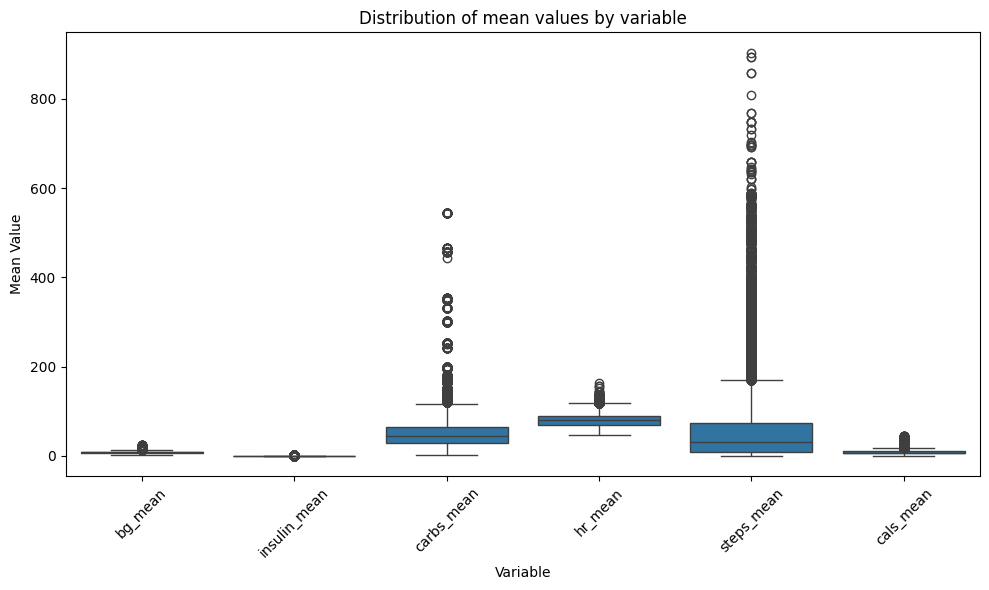

In [369]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=mean_long, x='Variable', y='Mean Value')
plt.title('Distribution of mean values by variable')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The variables bg_mean, insulin_mean, and cals_mean show more concentrated distributions with less variability in their mean values, generally in the low ranges.

hr_mean has a more centered distribution with fewer extreme outliers.

carbs_mean and steps_mean are the variables with the greatest dispersion and a significant number of high outliers, indicating greater variability in habits or measurements related to these variables. Steps_mean is particularly notable for the breadth of its distribution and the presence of numerous very high outliers.

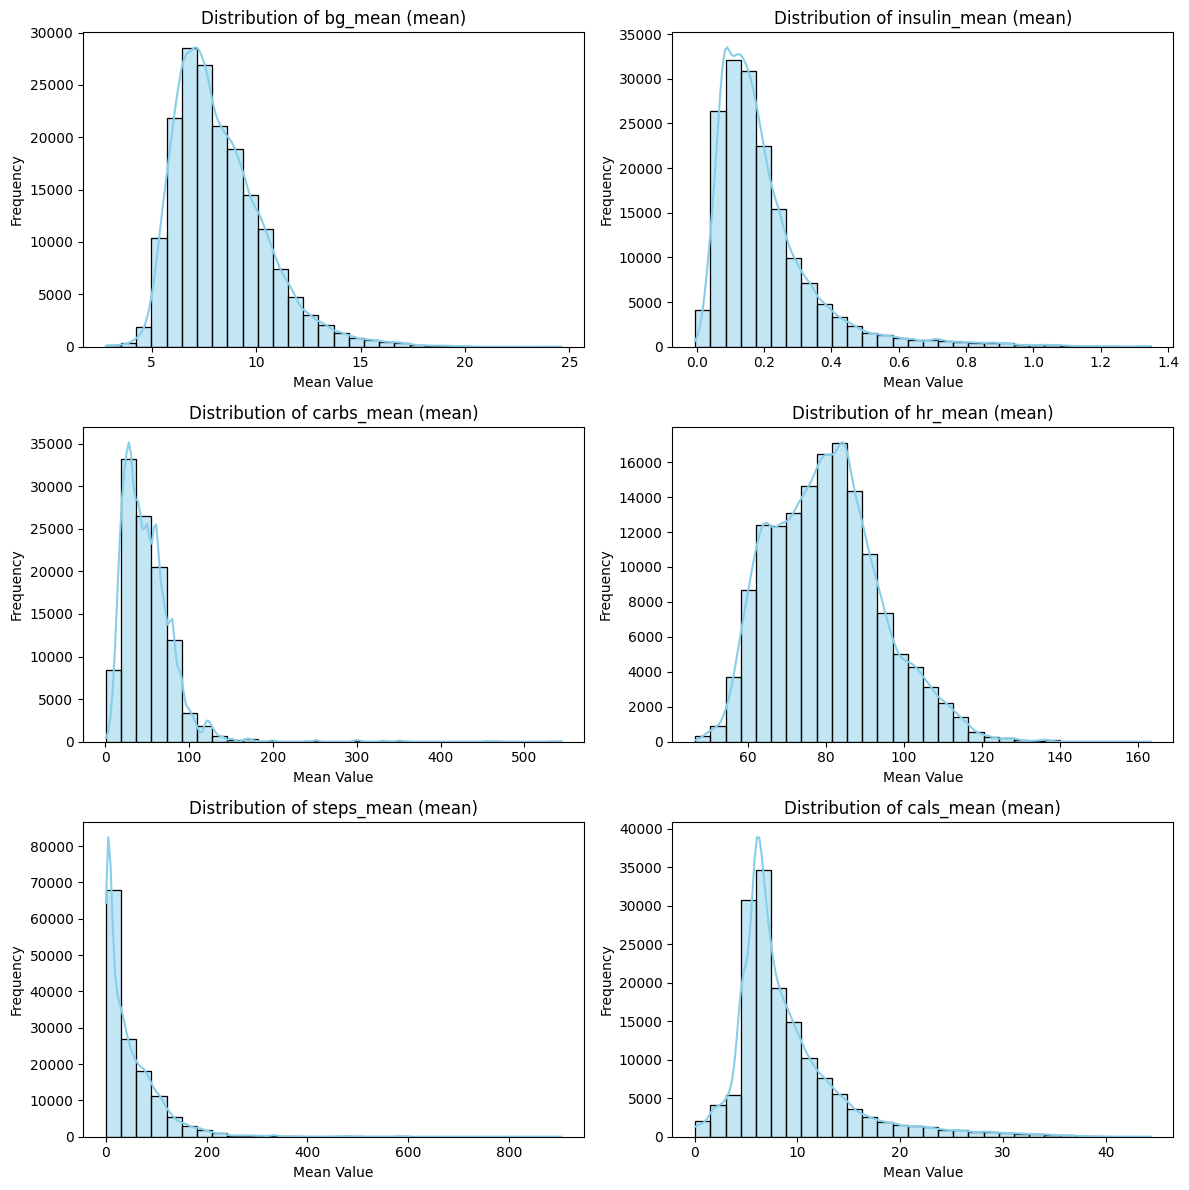

In [370]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables únicas
variables = mean_long['Variable'].unique()

# Crear subplots: 2 columnas, filas según número de variables
n_cols = 2
n_rows = -(-len(variables) // n_cols)  # Redondeo hacia arriba

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

# Histograma por variable
for i, var in enumerate(variables):
    sns.histplot(
        data=mean_long[mean_long['Variable'] == var],
        x='Mean Value',
        ax=axes[i],
        kde=True,
        bins=30,
        color='skyblue'
    )
    axes[i].set_title(f'Distribution of {var} (mean)', fontsize=12)
    axes[i].set_xlabel('Mean Value')
    axes[i].set_ylabel('Frequency')

# Quitar ejes vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



The steps_mean and cals_mean distributions are strongly positively skewed, meaning that most of the data are clustered at the lower end of their ranges.

steps_mean stands out for the high concentration of data in very low values and a very long tail with very high outliers, reflecting high variability in physical activity habits.

cals_mean is similar to bg_mean and insulin_mean in its strong bias toward low values, indicating that average caloric intakes are mostly low.

The dataset was downloaded from the page: https://data.bris.ac.uk/data/dataset/33z5jc8fa6tob21ptrugzqog08 and the data from the device_data/processed_state folder was exported for the patients indicated in Kaggle

In [371]:
p01 = pd.read_csv("P01.csv")
p02 = pd.read_csv("P02.csv")
p03 = pd.read_csv("P03.csv")
p04 = pd.read_csv("P04.csv")
p05 = pd.read_csv("P05.csv")
p06 = pd.read_csv("P06.csv")
p10 = pd.read_csv("P10.csv")
p11 = pd.read_csv("P11.csv")
p12 = pd.read_csv("P12.csv")

In [372]:
p02


,timestamp,bg,insulin,carbs,hr,dist,steps,cals,activity,device
0,2023-06-01 00:01:00,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dexcom G6
1,2023-06-01 00:05:00,NaN,0.1249,NaN,NaN,NaN,NaN,NaN,NaN,Tandem t:slim X2
2,2023-06-01 00:06:00,9.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dexcom G6
3,2023-06-01 00:10:00,NaN,0.0784,NaN,NaN,NaN,NaN,NaN,NaN,Tandem t:slim X2
4,2023-06-01 00:11:00,9.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dexcom G6
...,...,...,...,...,...,...,...,...,...,...
174851,2023-12-27 09:10:00,NaN,NaN,NaN,94.0,NaN,NaN,2.94,NaN,Apple Watch Series 5
174852,2023-12-27 09:14:00,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dexcom G6
174853,2023-12-27 09:15:00,NaN,NaN,NaN,91.0,14.9,19.0,5.00,NaN,Apple Watch Series 5
174854,2023-12-27 09:19:00,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dexcom G6


more frequent time intervals:

In [373]:
# Convert the date column to datetime format
p01['timestamp'] = pd.to_datetime(p01['timestamp'])

# Sort by timestamp if it's not sorted
p01 = p01.sort_values('timestamp')

# Calculate the difference between consecutive timestamps
p01['delta'] = p01['timestamp'].diff()

# Display the most common time intervals
print(p01['delta'].value_counts().head(10))

delta
0 days 00:00:00    62038
0 days 00:05:00    42710
0 days 00:02:00     8034
0 days 00:03:00     7933
0 days 00:01:00     7876
0 days 00:04:00     7628
Name: count, dtype: int64


convert "timestamp" to datetime

In [374]:
# Suppose you already have the DataFrames loaded as p01, p02, ..., p12

# Dictionary that groups them
dfs = {
    'p01': p01,
    'p02': p02,
    'p03': p03,
    'p04': p04,
    'p05': p05,
    'p06': p06,
    'p10': p10,
    'p11': p11,
    'p12': p12,
    }

# Converting to datetime
for name, df in dfs.items():
    df['timestamp'] = pd.to_datetime(df['timestamp'])


In [375]:
for name, df in dfs.items():
    df['day'] = df['timestamp'].dt.date  # Extract only the date part (without time)
    unique_days = df['day'].nunique()   # Count the unique days
    print(f"{name} tiene {unique_days} días únicos.")


p01 tiene 203 días únicos.
p02 tiene 210 días únicos.
p03 tiene 98 días únicos.
p04 tiene 219 días únicos.
p05 tiene 223 días únicos.
p06 tiene 201 días únicos.
p10 tiene 205 días únicos.
p11 tiene 222 días únicos.
p12 tiene 224 días únicos.


check if the data in each DataFrame is in chronological order

In [376]:
for name, df in dfs.items():
  is_sorted = df['timestamp'].is_monotonic_increasing
  print(f"{name} is in chronological order: {is_sorted}")


p01 is in chronological order: True
p02 is in chronological order: True
p03 is in chronological order: True
p04 is in chronological order: True
p05 is in chronological order: True
p06 is in chronological order: True
p10 is in chronological order: True
p11 is in chronological order: True
p12 is in chronological order: True


we extract only the first three months:

In [377]:
from datetime import timedelta

dfs_90days = {}  # Nuevo diccionario para guardar los dataframes filtrados

for name, df in dfs.items():
    start_date = df['timestamp'].min()
    end_date = start_date + timedelta(days=90)
    df_90 = df[df['timestamp'] < end_date].copy()
    dfs_90days[name] = df_90
    print(f"{name}: {df_90['timestamp'].min().date()} → {df_90['timestamp'].max().date()} | Filas: {len(df_90)}")


p01: 2023-06-01 → 2023-08-30 | Filas: 60179
p02: 2023-06-01 → 2023-08-30 | Filas: 77124
p03: 2023-06-01 → 2023-08-30 | Filas: 76182
p04: 2023-06-06 → 2023-09-04 | Filas: 75933
p05: 2023-06-01 → 2023-08-30 | Filas: 59559
p06: 2023-06-01 → 2023-08-30 | Filas: 58798
p10: 2023-06-01 → 2023-08-30 | Filas: 77022
p11: 2023-06-01 → 2023-08-30 | Filas: 64601
p12: 2023-06-01 → 2023-08-30 | Filas: 77120


resampling every 5 minutes:

In [378]:
for pid, df in dfs_90days.items():
    df = df.set_index("timestamp")             # Set 'timestamp' as index
    df = df.sort_index()                       # Sort the DataFrame by timestamp
    df_resampled = df.resample("5min").first() # Resample to 5-minute intervals, keeping the first value in each bin
    dfs_90days[pid] = df_resampled.reset_index() # Reset index and store back into the dictionary



In [379]:
dfs_90days["p01"].head()


,timestamp,bg,insulin,carbs,hr,dist,steps,cals,activity,device,delta,day
0,2023-06-01 00:05:00,8.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:01:00,2023-06-01
1,2023-06-01 00:10:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01
2,2023-06-01 00:15:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01
3,2023-06-01 00:20:00,9.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01
4,2023-06-01 00:25:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01


In [380]:
# Add the 'p_num' column to each DataFrame
for pid, df in dfs_90days.items():
    p_num = pid.split("_")[0] # Extract the patient code, e.g. 'p01'
    df['p_num'] = p_num
    dfs_90days[pid] = df
dfs_90days["p01"].head()

,timestamp,bg,insulin,carbs,hr,dist,steps,cals,activity,device,delta,day,p_num
0,2023-06-01 00:05:00,8.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:01:00,2023-06-01,p01
1,2023-06-01 00:10:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01,p01
2,2023-06-01 00:15:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01,p01
3,2023-06-01 00:20:00,9.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01,p01
4,2023-06-01 00:25:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01,p01


In [381]:
df_all = pd.concat(dfs_90days.values(), ignore_index=True)

In [382]:
df_all

,timestamp,bg,insulin,carbs,hr,dist,steps,cals,activity,device,delta,day,p_num
0,2023-06-01 00:05:00,8.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:01:00,2023-06-01,p01
1,2023-06-01 00:10:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01,p01
2,2023-06-01 00:15:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01,p01
3,2023-06-01 00:20:00,9.6,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:05:00,2023-06-01,p01
4,2023-06-01 00:25:00,NaN,0.0083,NaN,NaN,NaN,NaN,NaN,None,Medtronic MiniMed 640G,0 days 00:04:00,2023-06-01,p01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233281,2023-08-29 23:40:00,9.7,0.0000,NaN,90.0,4.8,7.0,34.07,None,Medtronic MiniMed 780G,NaT,2023-08-29,p12
233282,2023-08-29 23:45:00,9.8,0.0000,NaN,94.2,33.0,48.0,36.50,None,Medtronic MiniMed 780G,NaT,2023-08-29,p12
233283,2023-08-29 23:50:00,9.9,0.0000,NaN,97.6,6.8,10.0,31.37,None,Medtronic MiniMed 780G,NaT,2023-08-29,p12
233284,2023-08-29 23:55:00,9.8,0.0000,NaN,82.7,11.7,17.0,30.69,None,Fitbit Versa 4,NaT,2023-08-29,p12


Due to the way in which the data are arranged, it is very cumbersome to process them to obtain the same df, therefore all the values of the variables will be averaged by patients and the data will be compared.

In [383]:
# List of columns to average
variables = ['bg', 'insulin', 'carbs', 'hr', 'steps', 'cals']

# Calculate averages ignoring NaNs
averages = df_all[variables].mean(skipna=True)

# Convert to DataFrame (optional)
averages_df = pd.Series(averages, name="mean").to_frame()
print(averages_df)



              mean
bg        8.278703
insulin   0.193260
carbs    42.858234
hr       78.203309
steps    55.557082
cals      9.327919


In [384]:
# List of prefixes to average
prefixes = ["bg", "insulin", "carbs", "hr", "steps", "cals"]
# Dictionary to store the global average per variable
global_averages = {}

for prefix in prefixes:
    columns = [col for col in train.columns if col.startswith(prefix)]
    if columns:
        # Calculate the mean of all values across all columns with that prefix
        values = train[columns].values.flatten()
        mean_value = pd.Series(values).dropna().mean()
        global_averages[prefix] = mean_value

# Convert to DataFrame (optional)
df_averages = pd.Series(global_averages, name="mean").to_frame()
print(df_averages)



              mean
bg        8.236726
insulin   0.202988
carbs    48.227292
hr       79.314833
steps    53.095167
cals      9.361426


Compare the calculations of the averages

In [385]:
# First series (in DataFrame format)
mean1 = averages_df

# Second series (can come as a flat dict or Series)
mean2 = df_averages
common_vars = mean1.index.intersection(mean2.index)
common_vars

Index(['bg', 'insulin', 'carbs', 'hr', 'steps', 'cals'], dtype='object')

In [386]:
# Join both DataFrames by index
comparison = mean1.join(mean2, lsuffix='_1', rsuffix='_2', how='inner')


In [387]:
# Calculate absolute and relative difference
comparison["abs_diff"] = (comparison["mean_1"] - comparison["mean_2"]).abs()
comparison["rel_diff_%"] = comparison["abs_diff"] / (
(comparison["mean_1"] + comparison["mean_2"]) / 2
) * 100
comparison

,mean_1,mean_2,abs_diff,rel_diff_%
bg,8.278703,8.236726,0.041976,0.508330
insulin,0.193260,0.202988,0.009728,4.910210
carbs,42.858234,48.227292,5.369057,11.789046
hr,78.203309,79.314833,1.111523,1.411296
steps,55.557082,53.095167,2.461916,4.531735
cals,9.327919,9.361426,0.033507,0.358570


There are differences between the two sets of averages, with the change in carbohydrates being the most notable, while calories and blood glucose show the greatest stability.

The data set has another format and when you try to configure it from the same structure as the train, it is a rather cumbersome process that would require more time, even as much as the same EDA.

**Missing Data:** Identify missing data, if any, and suggest how to
manage it


In [388]:
# Count null values per column for each patient
nulls_per_patient = train.groupby("p_num").apply(lambda x: x.isna().sum())



/tmp/ipython-input-388-2378630639.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nulls_per_patient = train.groupby("p_num").apply(lambda x: x.isna().sum())


In [389]:
nulls_per_patient = nulls_per_patient.rename(columns={"p_num": "p_num_1"}).reset_index()
#sum of missing data for patient

In [390]:
prefixes = ["bg", "insulin", "carbs", "hr", "steps", "cals"]

# Select only columns that start with the specified prefixes
selected_columns = [col for col in nulls_per_patient.columns if any(col.startswith(prefix) for prefix in prefixes)]

# Create a new DataFrame with only those columns
train_selected = nulls_per_patient[selected_columns]

In [391]:
nulls_per_patient["total_nulls"] = nulls_per_patient.drop(columns=["p_num"]).sum(axis=1)

In [392]:
nulls_per_patient_sorted = nulls_per_patient.sort_values(by="total_nulls", ascending=False)

In [393]:
nulls_per_patient_sorted[["p_num", "total_nulls"]]

,p_num,total_nulls
1,p02,8066185
7,p11,6013668
3,p04,5721124
6,p10,5036419
2,p03,4816879
8,p12,4687348
4,p05,2169869
5,p06,1964052
0,p01,1819259


The one with the most missing data (total_nulls) is the participant with p_num = p02, with a total of 8,066,185 null values.

Now null according to the variables

In [394]:
# Define the prefixes of interest
prefixes = ["bg", "insulin", "carbs", "hr", "steps", "cals", "activity"]

# Create a dictionary where nulls by prefix will be stored
nulls_by_prefix = {}

# Iterate through each prefix, filter the corresponding columns, calculate nulls by patient, and store
for prefix in prefixes:
  cols = [c for c in train.columns if c.startswith(f"{prefix}-")]
  nulls_by_prefix[prefix] = train[cols].isna().groupby(train["p_num"]).sum().sum(axis=1)

In [395]:
# Combine everything into a single DataFrame
nulls_by_variable_and_patient = pd.DataFrame(nulls_by_prefix)

In [396]:
# Reset index so `p_num` is a normal column (optional)
nulls_by_variable_and_patient = nulls_by_variable_and_patient.reset_index()
nulls_by_variable_and_patient

,p_num,bg,insulin,carbs,hr,steps,cals,activity
0,p01,409686,0,599148,32689,186405,6252,585078
1,p02,22640,0,1839242,1464176,1566168,1328607,1845351
2,p03,18863,0,1851652,196203,782364,101844,1865952
3,p04,19507,0,1744331,879067,1117523,203292,1757403
4,p05,407515,0,587155,99260,347281,139284,589373
5,p06,407807,0,598281,118862,221574,29580,587947
6,p10,21642,0,1807092,136835,855589,448524,1766736
7,p11,28524,677556,1754561,668213,1047533,102636,1734644
8,p12,35500,0,1780392,113789,742497,199188,1815981


Higher numbers = more missing data.

Participants p02, p03, and p11 have large portions of missing values across most variables.

p01, p05, and p06 have the least missing data, especially for key variables like bg, carbs, and activity.

**insulin is almost entirely missing, except for p11, who may have partial data.** for wich we could consider to avoid use the data of this patient

In [397]:
# Identify the day with the most data (fewest nulls)

#count number of nan per day

non_null_counts = train.groupby('day_id').apply(lambda x: x.notnull().sum().sum())
best_day = non_null_counts.idxmax()
max_values = non_null_counts.max()
best_day, max_values

/tmp/ipython-input-397-1600811343.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  non_null_counts = train.groupby('day_id').apply(lambda x: x.notnull().sum().sum())


(np.int64(59), 657522)

The day with the fewest null values is the day 59  with 657522 non-null values.

Look at the time interval with the most null values

In [398]:
cols_of_interest = [col for col in train.columns if any(col.startswith(prefix) for prefix in prefixes)]
train['null_count'] = train[cols_of_interest].isnull().sum(axis=1)
nulls_by_time = train.groupby('time')['null_count'].sum().sort_values(ascending=False).reset_index()

In [399]:
nulls_by_time

,time,null_count
0,1900-01-01 06:25:00,160241
1,1900-01-01 06:55:00,159903
2,1900-01-01 06:40:00,159896
3,1900-01-01 07:10:00,159542
4,1900-01-01 07:25:00,159383
...,...,...
283,1900-01-01 17:55:00,124363
284,1900-01-01 18:50:00,124038
285,1900-01-01 18:05:00,124031
286,1900-01-01 18:35:00,124023


In [400]:
nulls_by_time['hour'] = pd.to_datetime(nulls_by_time['time'], errors='coerce').dt.time
nulls_by_time


,time,null_count,hour
0,1900-01-01 06:25:00,160241,06:25:00
1,1900-01-01 06:55:00,159903,06:55:00
2,1900-01-01 06:40:00,159896,06:40:00
3,1900-01-01 07:10:00,159542,07:10:00
4,1900-01-01 07:25:00,159383,07:25:00
...,...,...,...
283,1900-01-01 17:55:00,124363,17:55:00
284,1900-01-01 18:50:00,124038,18:50:00
285,1900-01-01 18:05:00,124031,18:05:00
286,1900-01-01 18:35:00,124023,18:35:00


It is suggested that patient p011 be eliminated, as it has the least data.
Additionally, it is suggested that imputations be made according to time windows.

#**Duplicate Checking:**# *Check for duplicates, if any, and decide what to
do with them*

Duplicates are not processed, as the dataset structure presents values by interval.

Only for the activity, the activity names are corrected, as mentioned in the code above.

#**Merging:**#  Explore if it is reasonable to merge the two datasets (train
and test) and briefly justify your decision.}

The merge is not performed because it is considered that there is enough data to perform initial model training. Including the test in the train or performing the merge implies greater complexity in an already complex dataset. It has too many null values and is difficult to process.

#**Graphs:**# Provide visuals of all of your insights and discussions

In [401]:
#Look at one day
train_day = train.copy()
train_day["day_id"] = train['day_id']
train_day["time"] = train["time"]
train_day["hour"] = train["hour"]
#predicted variable
train_day["bg+1:00"] = train["bg+1:00"]


In [402]:
train_day

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,...,activity-0:05,activity-0:00,bg+1:00,hour,minute,time_seconds,time_diff,new_day,day_id,null_count
0,p01_0,p01,1900-01-01 06:10:00,NaN,NaN,9.6,NaN,NaN,9.7,NaN,...,NaN,NaN,13.4,6,10,22200,NaN,0,0,408
1,p01_1,p01,1900-01-01 06:25:00,NaN,NaN,9.7,NaN,NaN,9.2,NaN,...,NaN,NaN,12.8,6,25,23100,900.0,0,0,408
2,p01_2,p01,1900-01-01 06:40:00,NaN,NaN,9.2,NaN,NaN,8.7,NaN,...,NaN,NaN,15.5,6,40,24000,900.0,0,0,408
3,p01_3,p01,1900-01-01 06:55:00,NaN,NaN,8.7,NaN,NaN,8.4,NaN,...,NaN,NaN,14.8,6,55,24900,900.0,0,0,408
4,p01_4,p01,1900-01-01 07:10:00,NaN,NaN,8.4,NaN,NaN,8.1,NaN,...,NaN,NaN,12.7,7,10,25800,900.0,0,0,408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177019,p12_25294,p12,1900-01-01 23:35:00,8.8,9.1,9.2,9.4,9.8,10.2,10.4,...,NaN,NaN,11.1,23,35,84900,300.0,0,91,286
177020,p12_25295,p12,1900-01-01 23:40:00,9.1,9.2,9.4,9.8,10.2,10.4,10.3,...,NaN,NaN,10.9,23,40,85200,300.0,0,91,286
177021,p12_25296,p12,1900-01-01 23:45:00,9.2,9.4,9.8,10.2,10.4,10.3,10.1,...,NaN,NaN,10.7,23,45,85500,300.0,0,91,286
177022,p12_25297,p12,1900-01-01 23:50:00,9.4,9.8,10.2,10.4,10.3,10.1,10.0,...,NaN,NaN,10.5,23,50,85800,300.0,0,91,286


In [403]:
#Graph the activity curves for each day for a patient
#1. Filter var- columns

import matplotlib.pyplot as plt
variables = ["bg-", "carbs-", "insulin-" "hr-", "steps-", "cals-"]
bg_cols = [col for col in train_day.columns if col.startswith("bg-")]
measurement_type = bg_cols[0].split("-")[0] if bg_cols else "?"

In [404]:
# 2. Choose the day you want to graph
selected_day = 59

# 3. Filter only the rows on the selected day
df_day = train_day[train_day["day_id"] == selected_day]


In [405]:
df_bg = df_day[["p_num", "day_id", "time", "hour"] + bg_cols].copy()
print(f"Datos disponibles para el día {selected_day}: {df_day.shape[0]} filas")
print(f"Columnas de glucosa (bg_cols): {bg_cols}")
# 2. Melt — pasamos de ancho a largo
df_melt = df_bg.melt(
    id_vars=["p_num", "day_id","hour", "time"],
    value_vars=bg_cols,
    var_name="bg_timepoint",
    value_name="bg_value"
)

Datos disponibles para el día 59: 2000 filas
Columnas de glucosa (bg_cols): ['bg-5:55', 'bg-5:50', 'bg-5:45', 'bg-5:40', 'bg-5:35', 'bg-5:30', 'bg-5:25', 'bg-5:20', 'bg-5:15', 'bg-5:10', 'bg-5:05', 'bg-5:00', 'bg-4:55', 'bg-4:50', 'bg-4:45', 'bg-4:40', 'bg-4:35', 'bg-4:30', 'bg-4:25', 'bg-4:20', 'bg-4:15', 'bg-4:10', 'bg-4:05', 'bg-4:00', 'bg-3:55', 'bg-3:50', 'bg-3:45', 'bg-3:40', 'bg-3:35', 'bg-3:30', 'bg-3:25', 'bg-3:20', 'bg-3:15', 'bg-3:10', 'bg-3:05', 'bg-3:00', 'bg-2:55', 'bg-2:50', 'bg-2:45', 'bg-2:40', 'bg-2:35', 'bg-2:30', 'bg-2:25', 'bg-2:20', 'bg-2:15', 'bg-2:10', 'bg-2:05', 'bg-2:00', 'bg-1:55', 'bg-1:50', 'bg-1:45', 'bg-1:40', 'bg-1:35', 'bg-1:30', 'bg-1:25', 'bg-1:20', 'bg-1:15', 'bg-1:10', 'bg-1:05', 'bg-1:00', 'bg-0:55', 'bg-0:50', 'bg-0:45', 'bg-0:40', 'bg-0:35', 'bg-0:30', 'bg-0:25', 'bg-0:20', 'bg-0:15', 'bg-0:10', 'bg-0:05', 'bg-0:00']


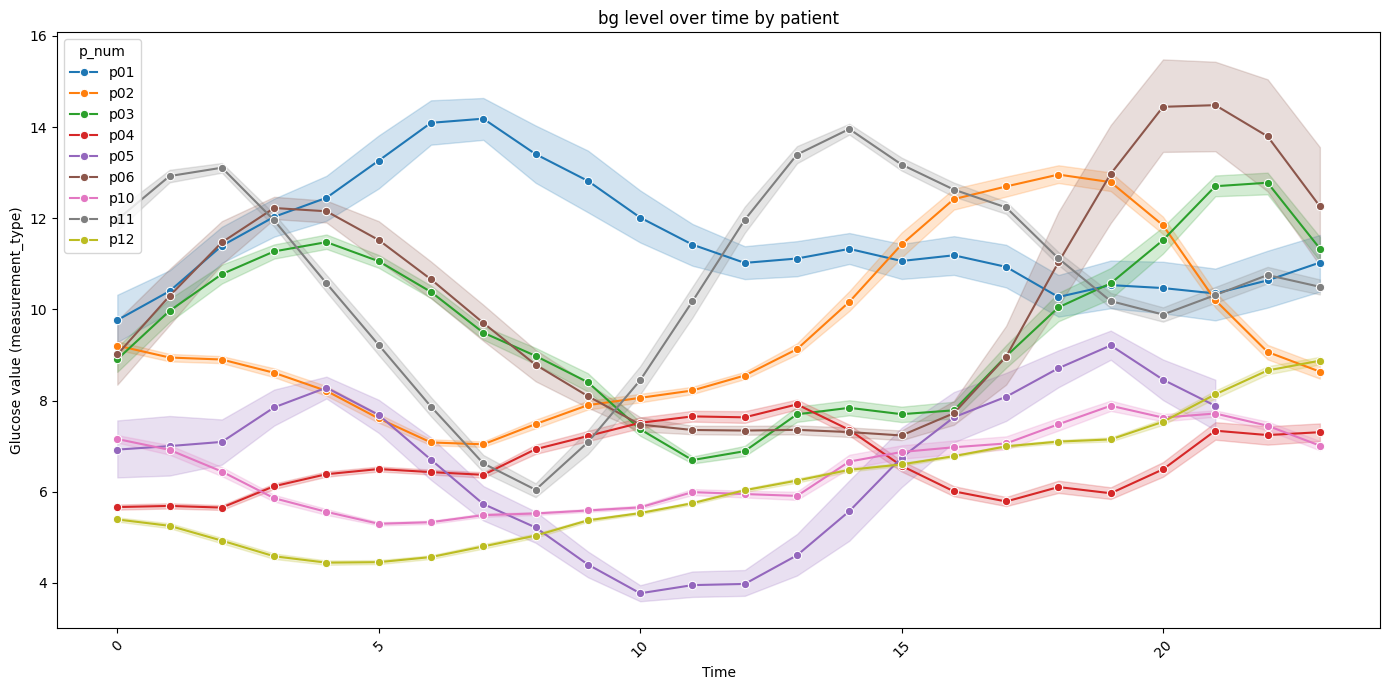

In [406]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_melt, x='hour', y='bg_value', hue='p_num', marker='o')
plt.title(f'{measurement_type} level over time by patient')
plt.xlabel('Time')
plt.ylabel(f'Glucose value (measurement_type)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


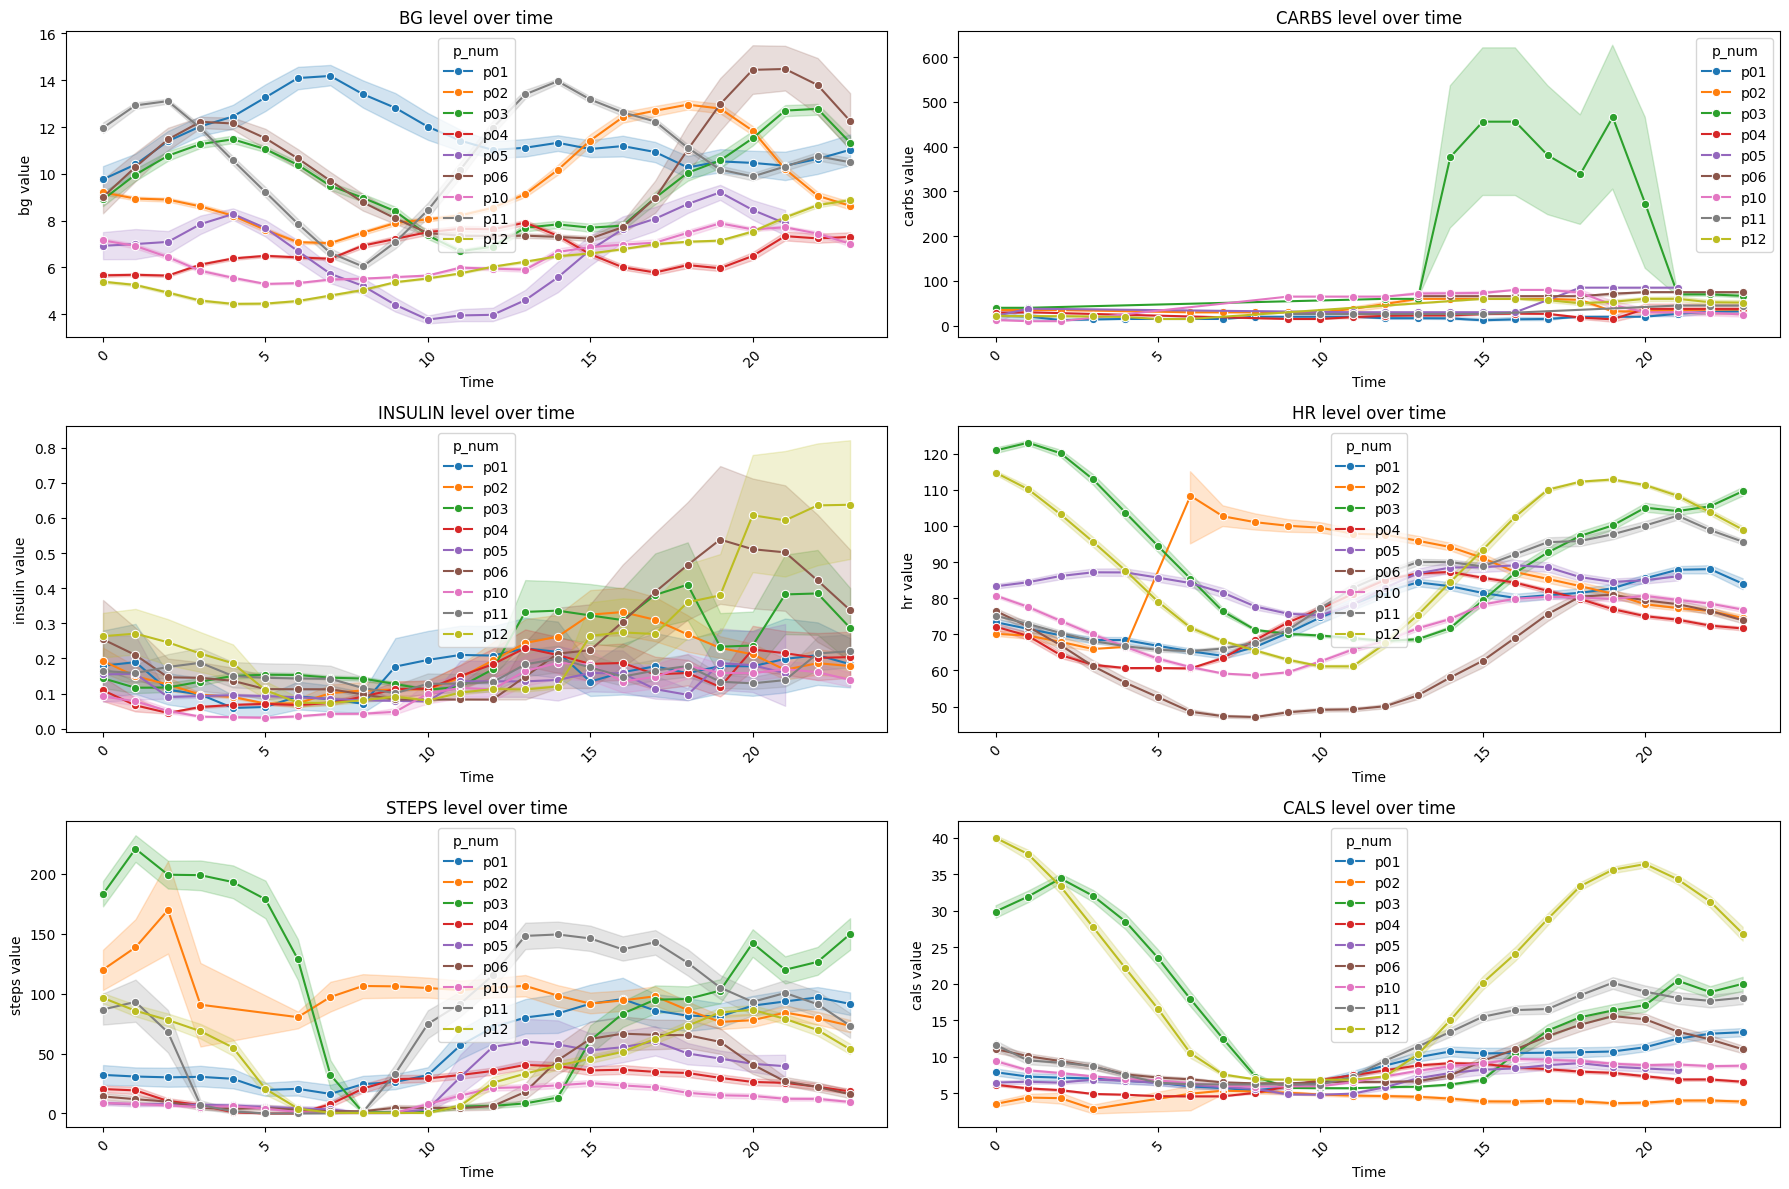

In [407]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables de interés
variables = ["bg-", "carbs-", "insulin-", "hr-", "steps-", "cals-"]

# Día a graficar
selected_day = 59
df_day = train_day[train_day["day_id"] == selected_day].copy()

# Crear figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 12), sharex=False)
axes = axes.flatten()

# Para cada variable
for i, prefix in enumerate(variables):
    # Selecciona columnas con ese prefijo
    cols = [col for col in train_day.columns if col.startswith(prefix)]
    if not cols:
        continue

    # Tipo de medición (ej. 'bg')
    measurement_type = cols[0].split("-")[0] if cols else prefix[:-1]

    # Seleccionar columnas para el día específico
    df_var = df_day[["p_num", "day_id", "time", "hour"] + cols].copy()

    # Melt para long format
    df_melt = df_var.melt(
        id_vars=["p_num", "day_id", "hour", "time"],
        value_vars=cols,
        var_name=f"{measurement_type}_timepoint",
        value_name=f"{measurement_type}_value"
    )

    # Graficar
    ax = axes[i]
    sns.lineplot(
        data=df_melt,
        x='hour',
        y=f"{measurement_type}_value",
        hue='p_num',
        marker='o',
        ax=ax
    )
    ax.set_title(f'{measurement_type.upper()} level over time')
    ax.set_xlabel("Time")
    ax.set_ylabel(f'{measurement_type} value')
    ax.tick_params(axis='x', rotation=45)

# Ajustar espacio
plt.tight_layout()
plt.show()


These graphs illustrate diurnal patterns of the monitored variables across different individuals. Some individuals show extreme spikes in variables such as carbohydrates and steps, while others maintain more stable profiles.

p03 stands out for having an extremely high peak carbohydrate intake around 3 p.m., far exceeding all other participants, and also exhibiting enormous variability at that time. In addition,  is one of the participants with the highest step activity in the morning, reaching a significant peak.

p12 stands out for being the participant with the highest calorie levels overal.

In [408]:
stats_df["p_num"] = train_day["p_num"]
stats_df["time"] = train_day["time"]
# Only derived numeric columns
numeric_cols = [col for col in stats_df.columns if any(col.startswith(v) for v in ["bg", "insulin", "carbs", "hr", "steps", "cals"]) and col != "p_num"]


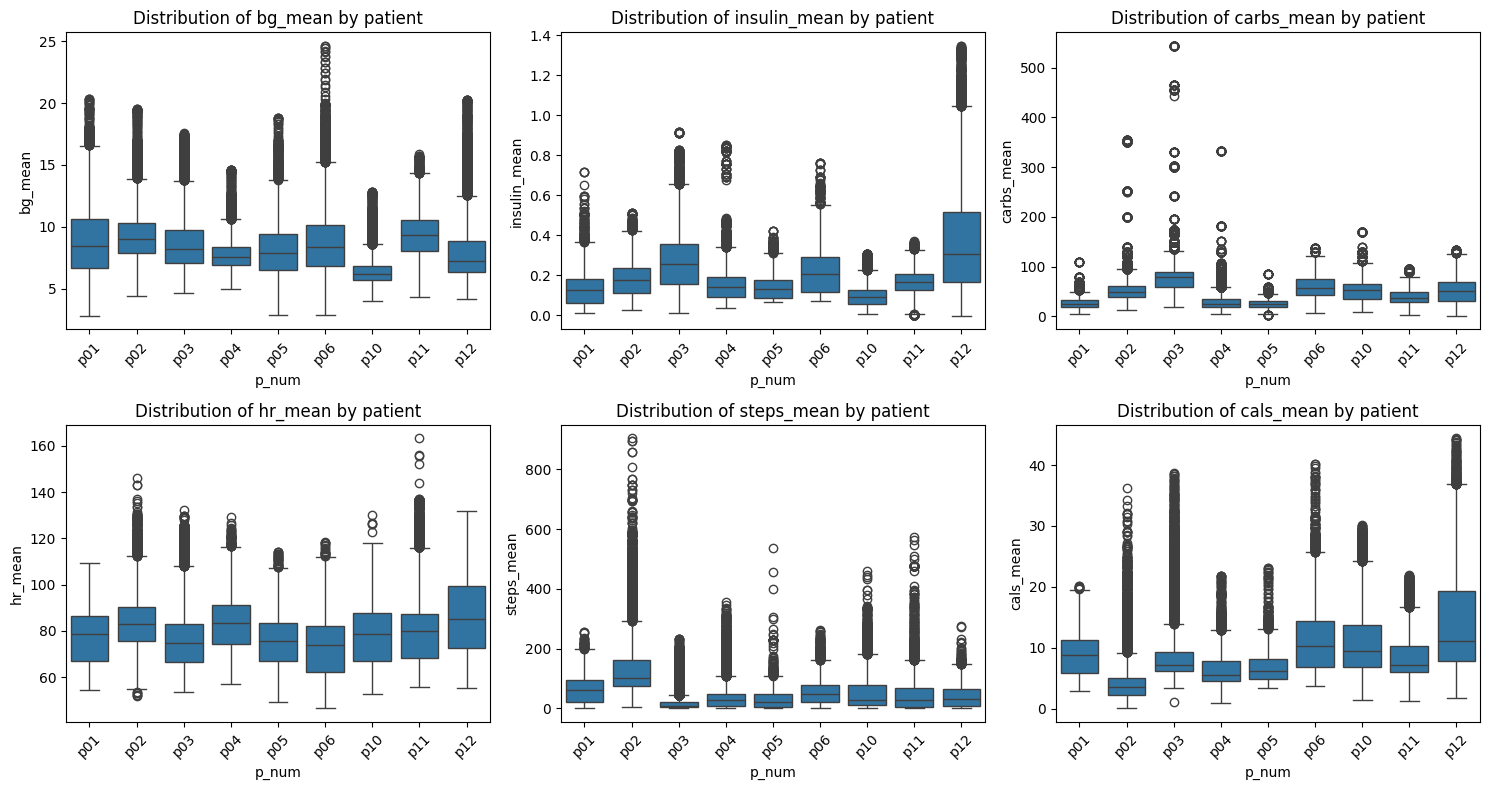

In [409]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Filter columns ending with '_mean'
mean_cols = [col for col in numeric_cols if col.endswith('_mean')]

# Number of plots per row in the grid
cols_per_row = 3

# Total number of plots
n = len(mean_cols)

# Calculate the number of rows needed
rows = math.ceil(n / cols_per_row)

# Create figure and axes
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*5, rows*4))
axes = axes.flatten()

# Generate boxplots in each subplot
for i, col in enumerate(mean_cols):
    sns.boxplot(data=stats_df, x="p_num", y=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by patient")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



The boxplots per patient reveal high individual variability in mean glucose (bg_mean), insulin (insulin_mean), and carbohydrate (carbs_mean) values. Although most patients had similar central ranges, numerous outliers indicating extreme events were observed. P03 stands out for its highly variable carbohydrate intake and extremely high peaks, P12 for its consistently high mean insulin levels, and P05 and P06 for showing abnormally high glucose values.

Patient p06 consistently shows a significantly lower average heart rate, setting them apart from the rest, while p02 exhibits the highest and most consistent step activity, suggesting a more active lifestyle. Meanwhile, p12 stands out with the highest average caloric intake and variability,

Ccorrelation between statistics and future glucose

In [410]:
mean_cols = [col for col in stats_df.columns if col.endswith("_mean")]
stats_df_with_target = stats_df[mean_cols].copy()
stats_df_with_target["bg+1:00"] = train_day["bg+1:00"]
corr_matrix = stats_df_with_target.corr()

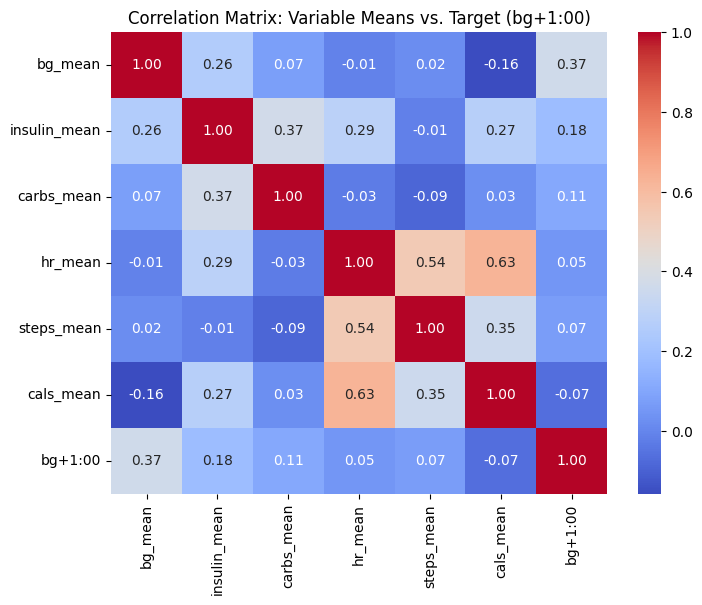

In [411]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Variable Means vs. Target (bg+1:00)")
plt.show()

hr_mean (heart rate) and cals_mean (calories) (0.63)have Strong positive correlation, a higher average heart rate is strongly associated with a higher average calorie intake.

hr_mean (heart rate) and steps_mean (steps) (0.54): Moderate to strong positive correlation. This is logical: the greater the activity (more steps), the higher the heart rate.

I applies unsupervised clustering with KMeans to group patients based on their
numerical characteristics from the summary_by_patient data frame. First, it standardizes the data so that all variables have the same scale (using StandardScaler), then runs KMeans  with two groups (clusters) and assigns each patient their respective cluster. Finally, it prints the number of patients in each group and lists the patient IDs belonging to each group.

#**Reflection:** What have you learned from this work? #

From this work, I’ve learned how to conduct an exploratory analysis of physiological and behavioral data collected from multiple patients. By generating and interpreting line plots, boxplots, and clustering results, I gained insights into inter- and intra-patient variability in metrics such as heart rate, steps, calorie intake, and glucose levels. I also practiced preprocessing techniques like handling null values, filtering columns by suffix, and scaling data for clustering. This process reinforced the importance of combining domain knowledge  with analytical tools to uncover meaningful patterns and individual differences that may not be evident from global averages.

#**Recommendations:**

*What would you suggest the researchers to do next?*

Se observaron que en las gráficas se encuentran diferentes comportamientos entre los apcientes por tantos y aconseja realizar una agrupación por ejemplo con KNN, usando métodos no supervisados. Además se recomienda promediar las columnas para que el intervalo de tiempo sea igual al de la columna time. Y se aconseja ver el comportamiento de las variables en temporalidad.

#**Summary:** Highlight the key findings of the report

It is observed that patient p11 is the only one with missing values for the insulin variable. Therefore, it is considered that this patient can be excluded for data analysis.

